In [1]:
import libraries as lb

In [2]:
inventory_data = lb.pd.read_csv("Dataset/inventory_stock_cleaned.csv")
inventory_data.dtypes

Medicine_ID                object
DrugName                   object
Formulation                object
Category                   object
Batch_No                   object
Manufacture_Date           object
Expiry_Date                object
Current_Stock               int64
Min_Required                int64
Max_Capacity                int64
Unit_Cost                 float64
Avg_Usage_Per_Day           int64
Restock_Lead_Time_Days      int64
Reorder_Level               int64
Stock_Cover_Days            int64
Vendor_ID                  object
Expiry_Risk                  bool
Inventory_Gap               int64
Stockout_Risk                bool
Reorder_Flag                 bool
Overstock_Flag               bool
Stock_per_Day             float64
dtype: object

# Medicines Below Reorder Level by Category 

In [3]:
inventory_data['Below_Reorder'] = (inventory_data['Current_Stock'] < inventory_data['Reorder_Level']).astype(int)
inventory_data['Below_Reorder']


0      0
1      1
2      0
3      0
4      0
      ..
836    0
837    0
838    0
839    0
840    0
Name: Below_Reorder, Length: 841, dtype: int64

# Group by Category

In [4]:
inventory_data["Category"].value_counts()

Category
Other                445
Oral                 186
Parenteral           181
Bulk/Raw Material     26
Oral Liquid            3
Name: count, dtype: int64

In [5]:
category_counts = (inventory_data[inventory_data['Below_Reorder'] == 1].groupby('Category')['Medicine_ID'].count().sort_values(ascending=False).reset_index())
category_counts.columns = ['Category', 'Count']
print("Medicines below reorder level by category:")
print(category_counts)

Medicines below reorder level by category:
            Category  Count
0              Other     14
1         Parenteral      8
2               Oral      4
3  Bulk/Raw Material      1


In [6]:
# "Other" Category medicines includes?
other_below = inventory_data[(inventory_data['Below_Reorder'] == 1) & (inventory_data['Category'] == 
                                                                       'Other')][['DrugName', 'Current_Stock', 'Reorder_Level', 'Category']]

print(other_below.to_string())

                                                      DrugName  Current_Stock  Reorder_Level Category
35                                     GLYCERYL TRINITRATE 5MG             63             85    Other
67                                     ATROPINE SULPHATE 0.6MG             81             89    Other
204                                PARACETAMOL 250MG / 5ML SYP             68             88    Other
228                                         SEVOFLURANE 99.97%             86            108    Other
240                                              ASPIRIN 150MG             66            102    Other
248                                              LORAZEPAM 2MG             68             75    Other
256                          GLICLAZIDE 80MG + METFORMIN 500MG             70            109    Other
264                                         LEVOSULPIRIDE 25MG             76             96    Other
579                          MOXIFLOXACIN 400MG/100ML IV FLUID             56     

# Plot

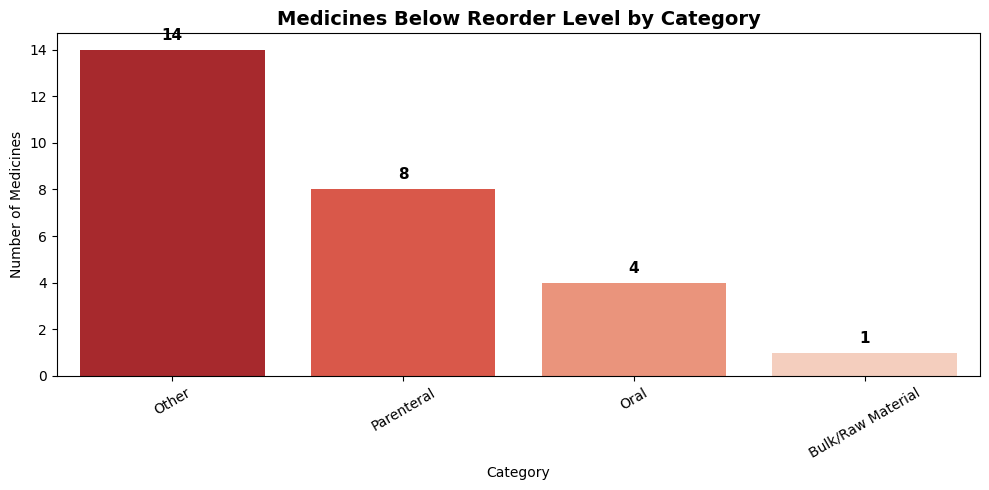

In [7]:
lb.plt.figure(figsize=(10, 5))
bars = lb.sns.barplot(data=category_counts,x='Category', y='Count',palette='Reds_r')

for bar, val in zip(bars.patches, category_counts['Count']):
    lb.plt.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                str(val), ha='center', va='bottom',
                fontweight='bold', fontsize=11)

lb.plt.title('Medicines Below Reorder Level by Category',fontsize=14, fontweight='bold')
lb.plt.xlabel('Category')
lb.plt.ylabel('Number of Medicines')
lb.plt.xticks(rotation=30)
lb.plt.tight_layout()
lb.plt.show()


# Observations

Other (14): Highest count includes critical cardiac drugs, antibiotics & anaesthetics, suggesting a data classification gap, not truly miscellaneous.

Parenteral (8): Injectable ICU drugs running low direct patient safety risk.

Oral (4): Below reorder but less critical than Parenteral in emergencies.

Bulk/Raw Material (1): Best managed strong procurement planning.

**Key Insight:** 
Reclassify "Other" drugs and immediately restock Parenteral medicines.

# Stockout vs Overstock vs Expiry Risk

In [8]:
stockout  = inventory_data['Stockout_Risk'].sum()
overstock = inventory_data['Overstock_Flag'].sum()
expiry    = inventory_data['Expiry_Risk'].sum()

print(f"Stockout Risk  : {stockout}")
print(f"Overstock Flag : {overstock}")
print(f"Expiry Risk    : {expiry}")

Stockout Risk  : 22
Overstock Flag : 176
Expiry Risk    : 168


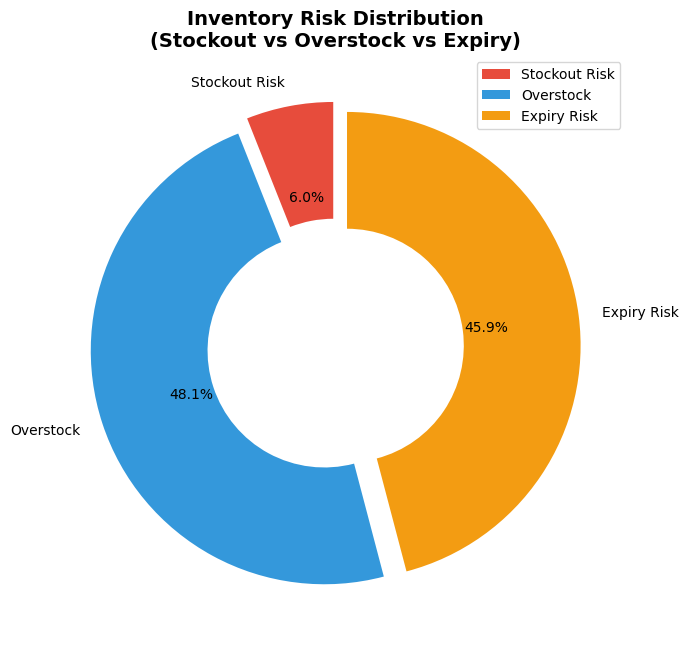

In [9]:
values = [stockout, overstock, expiry]
labels = ['Stockout Risk', 'Overstock', 'Expiry Risk']
colors = ['#e74c3c', '#3498db', '#f39c12']

# Plot
lb.plt.figure(figsize=(7, 7))
lb.plt.pie(
    values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0.05, 0.05),
    wedgeprops=dict(width=0.5)
)
lb.plt.title('Inventory Risk Distribution\n(Stockout vs Overstock vs Expiry)',
             fontsize=14, fontweight='bold')
lb.plt.legend(labels, loc='upper right')
lb.plt.tight_layout()
lb.plt.show()    

In [26]:
lb.plt.savefig('expiry_risk_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
lb.plt.show()


<Figure size 640x480 with 0 Axes>

## Observation — Inventory Risk Distribution

Overstock (48.1%) is the dominant risk nearly half the inventory is overstocked, tying up working capital.

Expiry Risk (45.9%) almost equals Overstock medicines are expiring before use, causing direct financial loss.

Stockout Risk (6.0%) is low but critical wrong medicines overstocked while right ones run short.

**Key Insight:** 
Poor demand forecasting is the root cause too much of the wrong stock, too little of the right stock.

# Wastage & Stockout by Region

In [10]:
consumption_data = lb.pd.read_csv("Dataset/consumption_facility_cleaned.csv")

# Group by Region — sum of Wastage_Flag and Stockout_Flag
heatmap_data = consumption_data.groupby('Region')[['Wastage_Flag','Stockout_Flag']].sum()

# Sort by total 
heatmap_data['Total'] = heatmap_data['Wastage_Flag'] + heatmap_data['Stockout_Flag']
heatmap_data = heatmap_data.sort_values('Total', ascending=False).drop('Total', axis=1)

print("Wastage & Stockout by Region:")
print(heatmap_data)

Wastage & Stockout by Region:
             Wastage_Flag  Stockout_Flag
Region                                  
Mumbai                204             39
Hyderabad             139             20
Chennai               122             19
Pune                  114             21
Delhi                 114             21
Indore                 97             25
Ahmedabad              96             24
Lucknow                88             19
Nagpur                 83             23
Jaipur                 81             20
Kolkata                85             14
Bangalore              77             15
Coimbatore             69             18
Guwahati               69             14
Bhubaneswar            36              5
Patna                  29              9
Kanpur                 31              3
Surat                  29              3
Raipur                 26              4


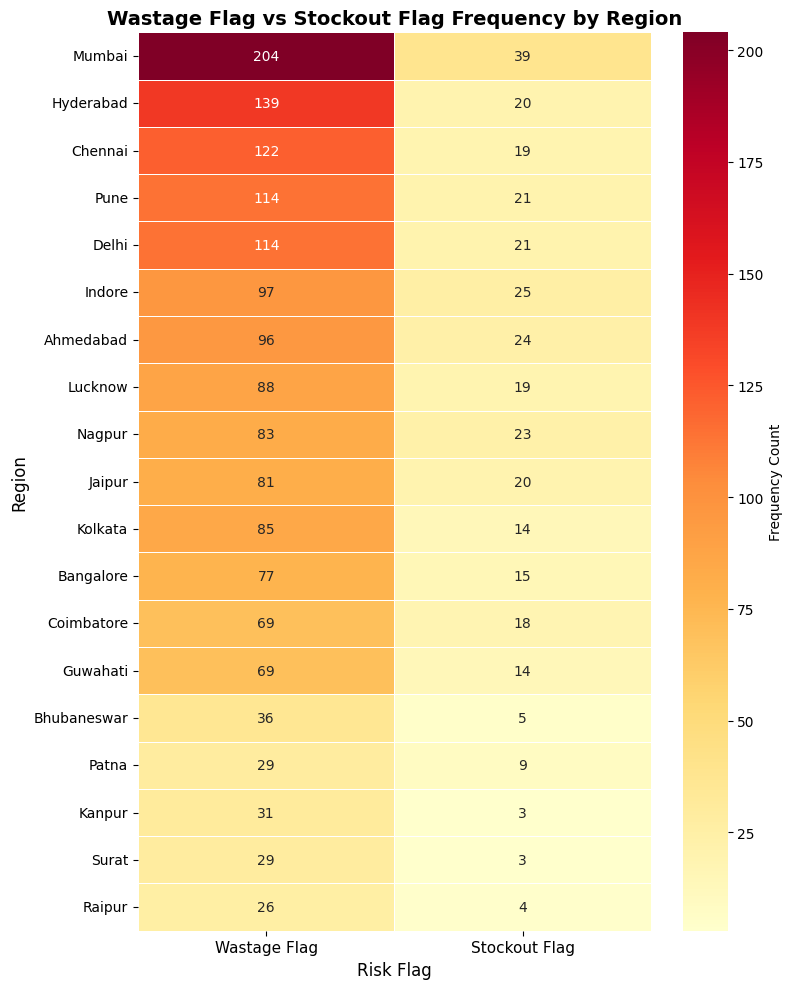

In [11]:
# Heatmap

lb.plt.figure(figsize=(8, 10))
lb.sns.heatmap(
    heatmap_data,
    annot=True,           
    fmt='d',              
    cmap='YlOrRd',        
    linewidths=0.5,       
    linecolor='white',
    cbar_kws={'label': 'Frequency Count'}
)

lb.plt.title('Wastage Flag vs Stockout Flag Frequency by Region',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Risk Flag', fontsize=12)
lb.plt.ylabel('Region', fontsize=12)
lb.plt.xticks(ticks=[0.5, 1.5],
              labels=['Wastage Flag', 'Stockout Flag'],
              fontsize=11)
lb.plt.tight_layout()
lb.plt.show()

In [12]:
# Group by Region — sum of Wastage_Flag and Stockout_Flag
heatmap_data = consumption_data.groupby('Region')[['Wastage_Flag', 'Stockout_Flag']].sum()

# Sort by total
heatmap_data['Total'] = heatmap_data['Wastage_Flag'] + heatmap_data['Stockout_Flag']
heatmap_data = heatmap_data.sort_values('Total', ascending=False).drop('Total', axis=1)
heatmap_data

,Wastage_Flag,Stockout_Flag
Region,,
Mumbai,204,39
Hyderabad,139,20
Chennai,122,19
Pune,114,21
Delhi,114,21
Indore,97,25
Ahmedabad,96,24
Lucknow,88,19
Nagpur,83,23


In [13]:
top5    = heatmap_data.head(5).copy()
bottom5 = heatmap_data.tail(5).copy()

top5['Rank']    = ['#1', '#2', '#3', '#4', '#5']
bottom5['Rank'] = ['#1', '#2', '#3', '#4', '#5']

def style_table(df, color):
    return (df.reset_index()
              .set_index('Rank')
              .style
              .background_gradient(
                  cmap='Reds' if color == 'red' else 'Greens',
                  subset=['Wastage_Flag', 'Stockout_Flag']
              )
              .format({'Wastage_Flag': '{:,}', 'Stockout_Flag': '{:,}'})
              .set_caption(
                  'Top 5 High Risk Regions' if color == 'red' 
                  else 'Bottom 5 Low Risk Regions'
              )
    )

display(style_table(top5,    color='red'))
print()
display(style_table(bottom5, color='green'))

,Region,Wastage_Flag,Stockout_Flag
Rank,,,
#1,Mumbai,204,39
#2,Hyderabad,139,20
#3,Chennai,122,19
#4,Pune,114,21
#5,Delhi,114,21


,Region,Wastage_Flag,Stockout_Flag
Rank,,,
#1,Bhubaneswar,36,5
#2,Patna,29,9
#3,Kanpur,31,3
#4,Surat,29,3
#5,Raipur,26,4


## Observation — Wastage & Stockout Frequency by Region

**Mumbai (204, 39)** is most critical highest wastage and stockout across all regions.

**Hyderabad, Chennai, Pune, Delhi** follow metro cities show consistent supply chain inefficiencies.

**Wastage >> Stockout** across all regions overstocking is a bigger problem than understocking.

**Indore & Ahmedabad** have higher Stockout Flags despite moderate wastage specific medicine shortages likely.

**Raipur, Surat, Kanpur** best managed, minimal risk.

- **Key Insight:** 
Metro cities need demand forecasting improvements; smaller cities need better supply chain connectivity.

# Region-wise Wastage Units vs Out-of-Stock Days

In [14]:
region_grouped = consumption_data.groupby('Region')[['Wastage_Units','Out_of_Stock_Days']].sum().reset_index()
region_grouped = region_grouped.sort_values('Wastage_Units', ascending=False)
print(region_grouped.to_string())

         Region  Wastage_Units  Out_of_Stock_Days
13       Mumbai            533                 80
5         Delhi            368                 37
7     Hyderabad            332                 48
3       Chennai            293                 35
14       Nagpur            264                 43
16         Pune            262                 39
1     Bangalore            258                 26
11      Kolkata            230                 30
8        Indore            221                 46
9        Jaipur            220                 43
0     Ahmedabad            208                 47
12      Lucknow            198                 37
4    Coimbatore            192                 36
6      Guwahati            180                 29
10       Kanpur            102                  6
15        Patna             94                 19
2   Bhubaneswar             71                 13
18        Surat             67                  4
17       Raipur             58                  6


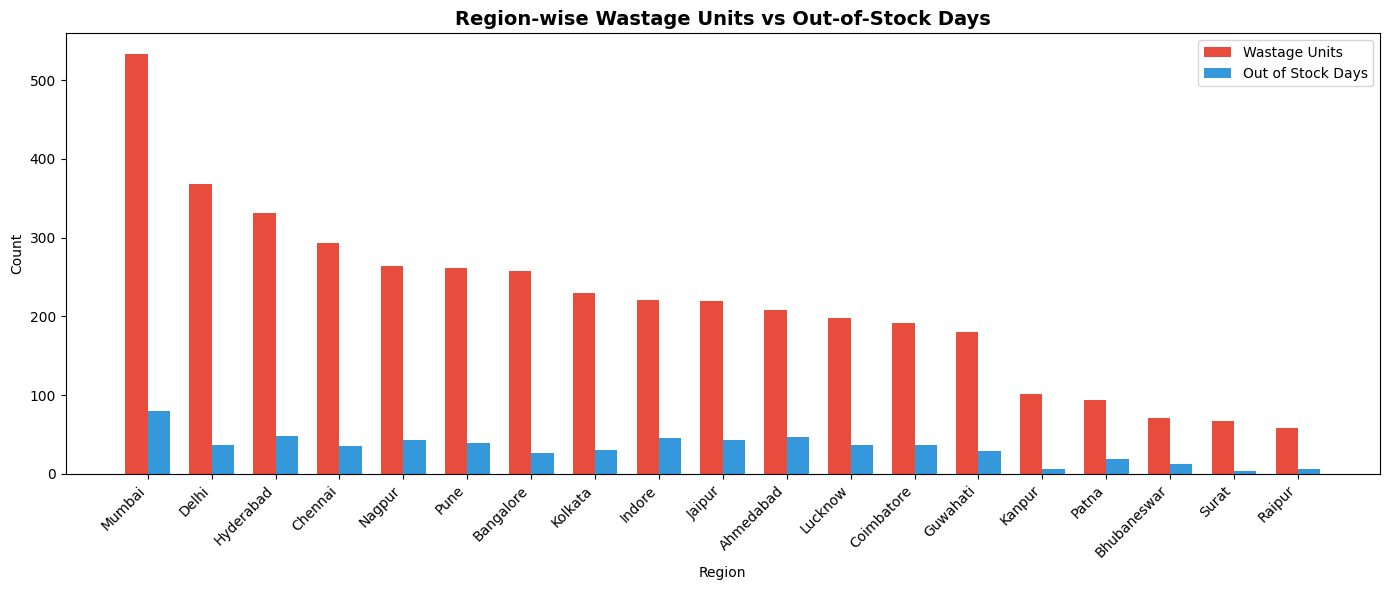

In [15]:
x = lb.np.arange(len(region_grouped))
width = 0.35

lb.plt.figure(figsize=(14, 6))
lb.plt.bar(x - width/2, region_grouped['Wastage_Units'],
           width, label='Wastage Units', color='#e74c3c')
lb.plt.bar(x + width/2, region_grouped['Out_of_Stock_Days'],
           width, label='Out of Stock Days', color='#3498db')

lb.plt.title('Region-wise Wastage Units vs Out-of-Stock Days',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Region')
lb.plt.ylabel('Count')
lb.plt.xticks(x, region_grouped['Region'], rotation=45, ha='right')
lb.plt.legend()
lb.plt.tight_layout()
lb.plt.show()

## Observation — Region-wise Wastage Units vs Out-of-Stock Days

**Mumbai (530 wastage, 78 stockout)** leads in both metrics highest medicine waste and most out-of-stock days across all regions.

**Delhi, Hyderabad, Chennai** follow with high wastage (300-370) metro cities consistently show poor inventory utilization.

**Out-of-Stock Days are significantly smaller than Wastage Units in every region** confirming overstocking is the primary supply chain problem.

**Kanpur, Patna, Bhubaneswar, Surat, Raipur** show the lowest wastage smaller cities manage inventory more efficiently.

**Key Insight:** 
    
Wastage and stockout move together regions with high wastage also tend to have more stockout days, suggesting systemic supply planning 
issues rather than isolated incidents.

# Consumption per Bed Day across Regions

In [16]:
region_order = (consumption_data.groupby('Region')['Consumption_per_Bed'].median().sort_values(ascending=False).index)
region_order

Index(['Bhubaneswar', 'Indore', 'Kanpur', 'Surat', 'Lucknow', 'Patna',
       'Ahmedabad', 'Bangalore', 'Guwahati', 'Chennai', 'Coimbatore', 'Jaipur',
       'Hyderabad', 'Delhi', 'Kolkata', 'Nagpur', 'Mumbai', 'Pune', 'Raipur'],
      dtype='object', name='Region')

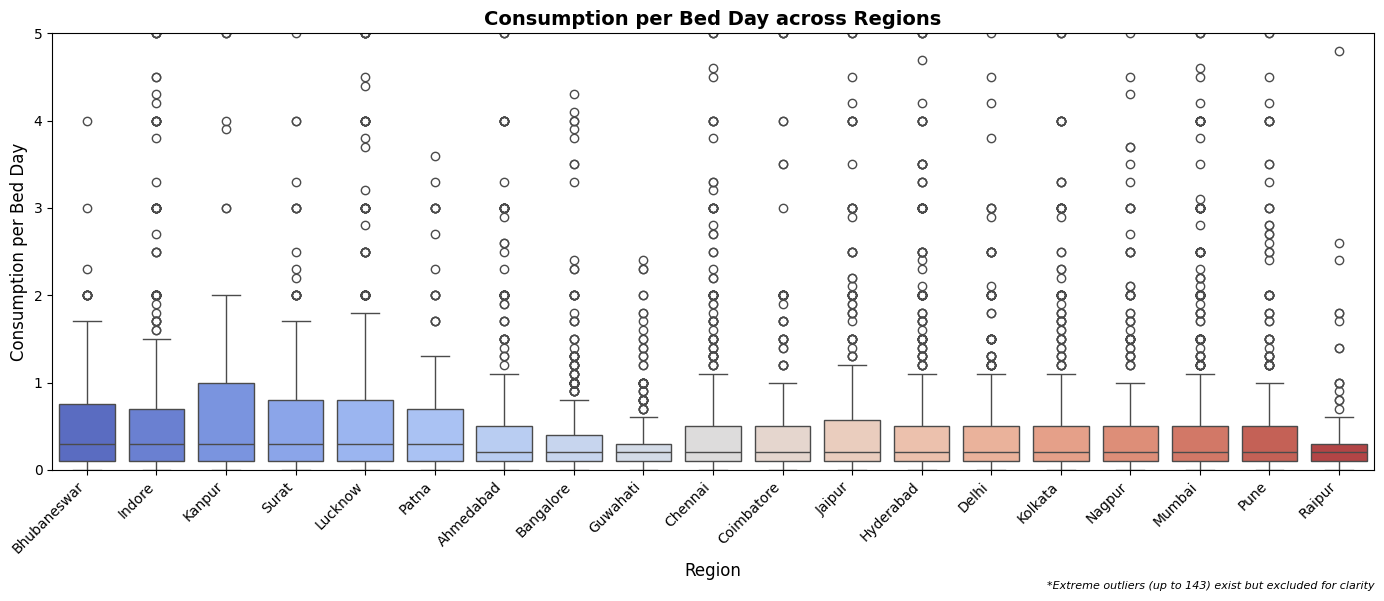

In [17]:
lb.plt.figure(figsize=(14, 6))
lb.sns.boxplot(data=consumption_data,x='Region',y='Consumption_per_Bed',order=region_order,palette='coolwarm')

lb.plt.ylim(0, 5)   
lb.plt.title('Consumption per Bed Day across Regions',fontsize=14, fontweight='bold')
lb.plt.xlabel('Region', fontsize=12)
lb.plt.ylabel('Consumption per Bed Day', fontsize=12)
lb.plt.xticks(rotation=45, ha='right')

lb.plt.figtext(0.99, 0.01, '*Extreme outliers (up to 143) exist but excluded for clarity',ha='right', fontsize=8, style='italic')
lb.plt.tight_layout()
lb.plt.show()

## Observation — Consumption per Bed Days across Regions

**Bhubaneswar, Indore, Kanpur** show patients in these regions consume more medicines per hospital stay.

**Raipur, Pune, Mumbai** despite being larger cities, more controlled prescription practices.

**All regions have numerous outliers (dots above boxes)** indicating occasional extremely high consumption events, likely ICU or critical care cases.

**Guwahati and Chennai** shows most consistent consumption patterns with least variability.

- **Key Insight:** 
Consumption per bed day varies significantly across regions standardized prescription 
protocols could help reduce this variation and improve medicine planning.

*Note: Extreme outliers up to 143 exist but excluded from chart for clarity.*

# Procurement Cost & Profit Efficiency

# Return Units Impact on Profit 

In [18]:
# Return Units Impact on Profit 
demand_data=lb.pd.read_csv("Dataset/demand_sales_cleaned.csv")
# Calculate Return_Percentage for returned orders only
demand_data['Return_Percentage'] = demand_data.apply(
    lambda r: r['ReturnQuantity'] 
    if r['Order_Status'] == 'Returned' 
    else lb.np.nan, axis=1
)

print("Non-zero Return_Percentage:", 
      (demand_data['Return_Percentage'] > 0).sum())
print(demand_data['Return_Percentage'].describe().round(2))

# Bin Return Units 
demand_data['Return_Bin'] = lb.pd.cut(
    demand_data['Return_Percentage'],
    bins=[0, 1, 2, 5, 10, 50],
    labels=['1 unit', '2 units', '3-5 units',
            '6-10 units', '10-50 units']
)

#  Group by Return Bin 
return_profit = demand_data.groupby('Return_Bin')['Profit'].mean().reset_index()
return_profit.columns = ['Return_Units', 'Avg_Loss']
print(return_profit)

Non-zero Return_Percentage: 1681
count    1681.00
mean        2.47
std         4.18
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        50.00
Name: Return_Percentage, dtype: float64
  Return_Units    Avg_Loss
0       1 unit  -96.015771
1      2 units -147.592475
2    3-5 units -126.399395
3   6-10 units -114.662083
4  10-50 units  -85.043191


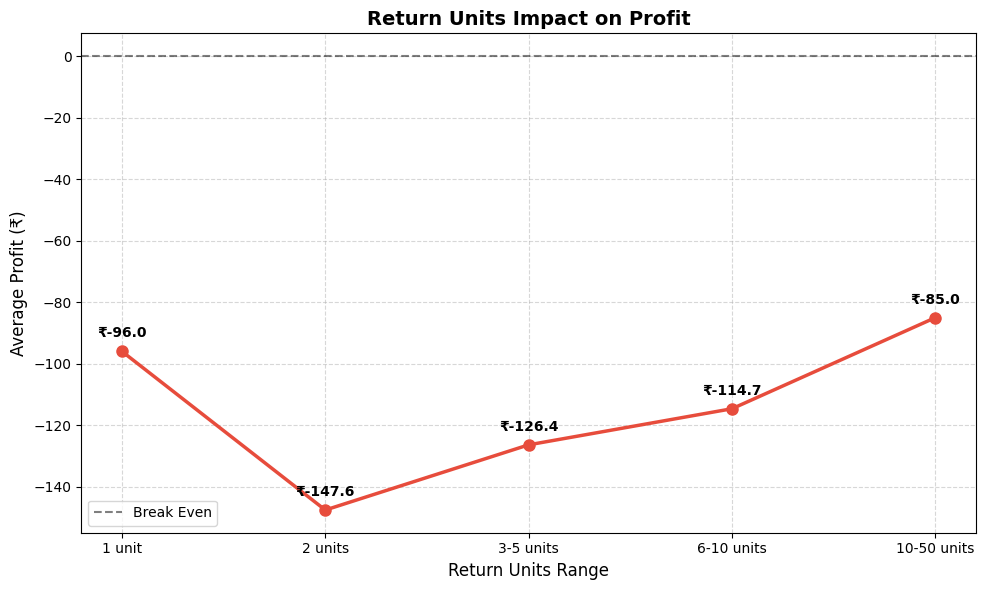

In [19]:
# ── Line Chart ──────────────────────────────────────────
lb.plt.figure(figsize=(10, 6))
lb.plt.plot(return_profit['Return_Units'],
            return_profit['Avg_Loss'],
            marker='o',
            color='#e74c3c',
            linewidth=2.5,
            markersize=8)

for i, row in return_profit.iterrows():
    lb.plt.annotate(f"₹{row['Avg_Loss']:.1f}",
                    (i, row['Avg_Loss']),
                    textcoords='offset points',
                    xytext=(0, 10),
                    ha='center',
                    fontsize=10,
                    fontweight='bold')

lb.plt.axhline(y=0, color='black',
               linestyle='--', alpha=0.5,
               label='Break Even')

lb.plt.title('Return Units Impact on Profit',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Return Units Range', fontsize=12)
lb.plt.ylabel('Average Profit (₹)', fontsize=12)
lb.plt.grid(True, linestyle='--', alpha=0.5)
lb.plt.legend()
lb.plt.tight_layout()
lb.plt.show()

## Observation Return Units Impact on Profit
 
**All returns cause loss** profit is negative across all return unit ranges.

**2 units (₹-147.6)** causes highest loss, worse than even bulk returns, likely involves expensive medicines.

**10-50 units (₹-85.0)** shows lowest loss bulk returns likely involve cheaper medicines.

- **Key Insight:** 
    
Even 1 unit return causes ₹96 loss reducing return frequency is more important than return quantity.

# Unit Cost vs Profit Margin by Category

In [20]:
# avg unit cost per drug
inventory_clean = inventory_data.copy()
inventory_clean['DrugName'] = inventory_clean['DrugName'].str.strip()

unit_cost = inventory_clean.groupby(['DrugName','Category'])['Unit_Cost'].mean().reset_index()

# avg profit margin per drug
demand_clean = demand_data[demand_data['Order_Status'] == 'Delivered'].copy()
demand_clean['DrugName'] = demand_clean['DrugName'].str.strip()
demand_clean['Profit_Margin'] = ((demand_clean['Profit'] / demand_clean['Final_Sales']) * 100).round(2)

profit_margin = demand_clean.groupby('DrugName')['Profit_Margin'].mean().reset_index()

#  Merge
merged = unit_cost.merge(profit_margin, on='DrugName', how='inner')
print("Merged shape:", merged.shape)
print(merged.head())
print(merged.describe().round(2))

Merged shape: (693, 4)
                                            DrugName Category  Unit_Cost  \
0                                                       Other    105.645   
1                           ACEBROPHYLLINE 100MG CAP     Oral    103.910   
2                           ACEBROPHYLLINE 200MG TAB     Oral    163.710   
3  ACECLOFENAC 100MG + PARACETAMOL 325MG + SERRAT...     Oral     17.520   
4          ACECLOFENAC 100MG + PARACETAMOL 325MG TAB     Oral    144.055   

   Profit_Margin  
0      49.639626  
1      10.310000  
2      12.648000  
3       9.106000  
4       5.853333  
       Unit_Cost  Profit_Margin
count     693.00         693.00
mean      100.58          21.36
std        55.37          19.18
min         5.16          -1.23
25%        52.78           7.68
50%       101.10          13.89
75%       145.67          31.03
max       199.88          88.35


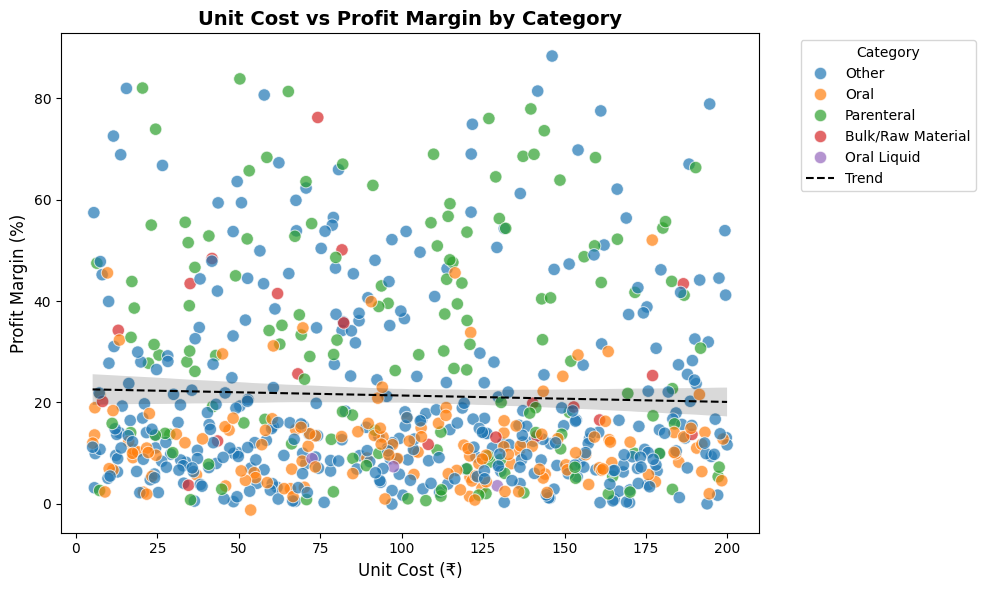

In [21]:
# Scatter Plot 
lb.plt.figure(figsize=(10, 6))
lb.sns.scatterplot(data=merged,
                   x='Unit_Cost',
                   y='Profit_Margin',
                   hue='Category',
                   palette='tab10',
                   alpha=0.7,
                   s=80)
lb.sns.regplot(data=merged,
               x='Unit_Cost',
               y='Profit_Margin',
               scatter=False,
               color='black',
               line_kws={'linestyle':'--','linewidth':1.5},
               label='Trend')
lb.plt.title('Unit Cost vs Profit Margin by Category',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Unit Cost (₹)', fontsize=12)
lb.plt.ylabel('Profit Margin (%)', fontsize=12)
lb.plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
lb.plt.tight_layout()
lb.plt.show()

## Observation — Unit Cost vs Profit Margin by Category

** Merged on DrugName** 693 common medicines found across inventory and demand datasets.

**Weak relationship** between unit cost and profit margin trend line is nearly flat.

**Parenteral (green)** shows highest margin variability ranges from 0% to 80%+.

**Oral (orange)** clusters at lower margins (0-20%) high competition drives margins down.

**Other (blue)** has highest margin outliers (80%+) specialty medicines command premium.

- **Key Insight:** 
    
Profit margin depends on medicine type, not unit cost. Prioritize high-margin Parenteral and specialty medicines.

# Order Status Distribution 

In [22]:
status_counts = demand_data['Order_Status'].value_counts()
print("Order Status Counts:")
print(status_counts)


Order Status Counts:
Order_Status
Delivered    11310
Returned      1681
Cancelled      633
Pending        594
Name: count, dtype: int64


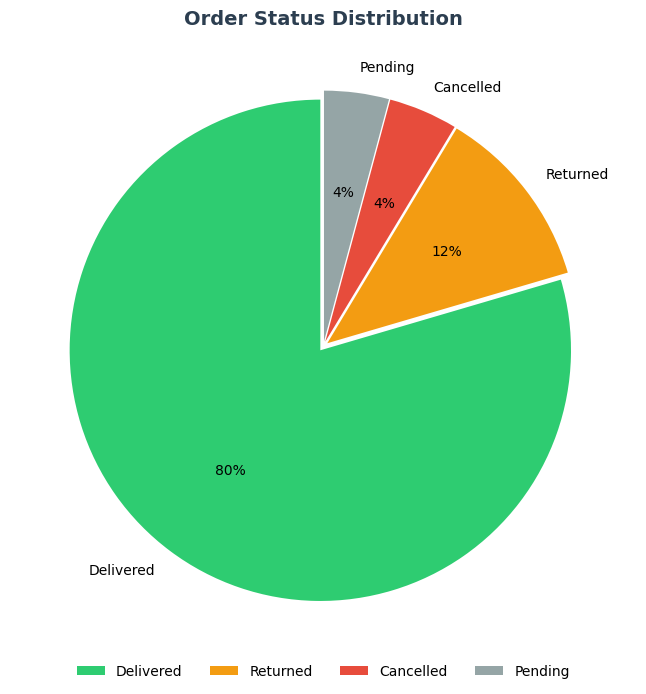

In [23]:
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']
explode = (0.02, 0.02, 0.02, 0.02)

lb.plt.figure(figsize=(7, 7))
lb.plt.pie(
    status_counts,
    labels=status_counts.index,
    colors=colors,
    autopct='%1.0f%%',
    startangle=90,
    explode=explode
)

lb.plt.title('Order Status Distribution',
             fontsize=14, fontweight='bold',
             color='#2c3e50')
lb.plt.legend(
    status_counts.index,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,
    frameon=False
)
lb.plt.tight_layout()
lb.plt.show()
